In [1]:
import os

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# !conda install -y -c conda-forge pandas geopandas matplotlib numpy shapely contextily openpyxl

In [3]:
def clean_hh_geoid(geoid):
    """
    Homelands census datasets have core geoid identifier while geojson uses the full geoid.
    e.g. Waiamanlo is represented as 155271T in geojson and 5271 in census datasets.
    Process geojson GEOID10 to match census dataset format for geoid
    """
    if isinstance(geoid, str):
        if geoid.startswith('15'):
            geoid = geoid[2:]
        if geoid.endswith('T'):
            geoid = geoid[:-1]
    return geoid

In [4]:
# census_data = pd.read_csv(f'./age_of_structure.csv')

# # census_data = pd.read_csv(f'/home/shared/SCOVI/cleaned-data/census/age_of_structure.csv')

# print(f"Shape: {census_data.shape}")
# print(census_data.head(2))
# print("\nColumn names:")
# print(census_data.columns.tolist())

In [53]:
file = "On-site_Sewage_Disposal_Systems_-_Oahu"
gdf = gpd.read_file(f'/Users/andyyu/Desktop/GIS Data/done/On-site_Sewage_Disposal_Systems_-_Molokai/On-site_Sewage_Disposal_Systems_-_Molokai.shp')

print(f"Shape: {gdf.shape}")
print(f"Columns: {gdf.columns.tolist()}")
print(gdf.head(3))

Shape: (1651, 35)
Columns: ['objectid', 'island', 'tmk', 'bldgval', 'bldexem', 'pittcode', 'homeownr', 'gisacres', 'osds_qty', 'class_i', 'class_ii', 'class_iii', 'class_iv', 'effluent', 'n_flux', 'p_flux', 'commercial', 'source', 'no_struct', 'ttl_bdrms', 'no_bath', 'prmt_no', 'prmt_id', 'uic_no', 'inject', 'wwtp', 'class', 'type', 'ownr_typ', 'wwtp_ownr', 'contact', 'eng', 'op_drc', 'comments', 'geometry']
   objectid   island        tmk  bldgval  bldexem  pittcode homeownr  \
0         1  Molokai  252023001    33200    33200       300        N   
1         2  Molokai  252023036    61500    61500       300        N   
2         3  Molokai  251002001   787600   787600       999        N   

      gisacres  osds_qty  class_i  ...  wwtp  class  type  ownr_typ  \
0     0.426201         1        1  ...  None  -9999  None      None   
1     0.257674         1        0  ...  None  -9999  None      None   
2  4752.027347        10        0  ...  None  -9999  None      None   

   wwtp_ownr  

In [54]:
print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
print(f"CRS: {gdf.crs}")

Geometry types: ['Point']
CRS: EPSG:3750


<Axes: >

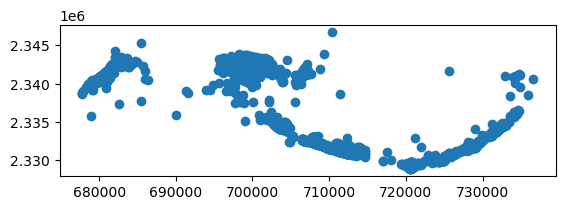

In [55]:
gdf.plot()

In [56]:
# Change to be compatible with leaflet
gdf = gdf.to_crs(epsg=4326)

In [58]:
gdf.to_file(f'~/Desktop/On-site_Sewage_Disposal_Systems_-_Molokai.geojson', driver='GeoJSON')

### Quick visualization of gis data

In [ ]:
print(f"Loaded shapefile with {len(gdf)} features")
print(f"Columns: {gdf.columns.tolist()}")
print(f"First row: {gdf.iloc[0]}")

# Create a simple visualization of the block groups
fig, ax = plt.subplots(figsize=(12, 8))

# Color by an existing column in the shapefile - 'pop20' is usually available
# Change 'pop20' to any column that exists in your shapefile
gdf.plot(column='geometry', cmap='Blues', linewidth=0.5, 
         ax=ax, edgecolor='k', legend=True)

# Add a title
plt.title('Census Block Groups')

# Display the map
plt.tight_layout()
plt.show()

# Save the map as an image file
plt.savefig('census_map.png', dpi=300, bbox_inches='tight')
print("Map saved as 'census_map.png'")

## Convert to geoJSON for leaflet

In [ ]:
output_path = './2020_Census_Block_Groups_WGS84.geojson'
gdf.to_file(output_path, driver='GeoJSON')

## Demo download from koa cloud using API

### For env variables, create a .env file with variables and values

In [ ]:
import os
from dotenv import load_dotenv
from nc_py_api import Nextcloud

load_dotenv()

# Get credentials from environment variables
nc_url = os.environ.get("NEXTCLOUD_URL", "")
nc_user = os.environ.get("NEXTCLOUD_USER", "")
nc_pass = os.environ.get("NEXTCLOUD_PASS", "")

# Connect only if credentials are available
if nc_url and nc_user and nc_pass:
    nc = Nextcloud(
        nextcloud_url=nc_url,
        nc_auth_user=nc_user,
        nc_auth_pass=nc_pass
    )
else:
    print("Nextcloud credentials not found in environment variables")

In [ ]:
# nc.files.download("SCOVI Project/Metrics/All Exposures/census/cleaned-data/age_of_structure.csv")

In [ ]:
# pretty_capabilities = dumps(nc.capabilities, indent=4, sort_keys=True)
# print(pretty_capabilities)

In [ ]:
# print("Files & folders on the instance for the selected user:")
# all_files_folders = nc.files.listdir(r"SCOVI Project", depth=-1)
# for obj in all_files_folders:
#     print(obj.user_path)